# Extension of Diversity Vector to Narrative Diversity (D_narr)

-> Sentiment trajectory divergence across stories

**Approach:**
- For each story extract a normalized sentiment arc
- Per-sentence sentiment from the transformer classifier `siebert/sentiment-roberta-large-english` (VADER as an appendix for comparison against a lexicon-based approach)
- Binned into 10 equal-proportion narrative segments and averaged per segment
- Narrative diversity per prompt-source group via mean pairwise Euclidean distance between arcs

**Reference:** Reagan et al. (2016) found that the emotional arcs of stories are dominated by six basic shapes (theoretical framing but we do not reproduce their lexicon-based sentiment scoring)

**Metric formula:**
$$D_{\text{narr}} = \frac{1}{\binom{n}{2}} \sum_{i < j} \| \mathbf{a}_i - \mathbf{a}_j \|_2$$
where $\mathbf{a}_i$ is the binned sentiment arc of story $i$.

**Data:**
Generated data from `data_generation/generations/` switchable via `DOMAIN`:
- **`storytelling_n200`**: WritingPrompts (Fan et al., 2018) test split, 200 prompts x 4 LLMs x 5 samples + >=5 human reference stories/prompt
- **`translation_ref3`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=3 human translations/paragraph
- **`translation_ref4`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=4 human translations/paragraph

Note: a sentiment arc needs MIN_SENTENCES=10 (>= ARC_LENGTH) sentences per text. Par3 paragraphs
are often much shorter than full WritingPrompts stories, so the translation domains may retain
noticeably fewer valid texts/groups than storytelling_n200

In [29]:
# Load libraries
import json
import time
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency, entropy as scipy_entropy
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import nltk
from nltk.tokenize import sent_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

warnings.filterwarnings('ignore')
np.random.seed(42)

In [30]:
# Download NLTK punkt tokenizer
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Print-oriented plotting defaults
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'legend.fontsize': 10,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10})

In [31]:
# Configuration
DOMAIN = 'translation_ref3'  # 'storytelling_n200', 'translation_ref3' or 'translation_ref4'

ARC_LENGTH = 10          # number of points to bin each sentiment arc into
MIN_SENTENCES = 10       # minimum sentences required to include a story (must be >= ARC_LENGTH)

# Minimum valid stories required for a (prompt, source) group to be included: 
# same >=2 pairwise minimum used throughout
MIN_STORIES_PER_GROUP = 2

SENTIMENT_METHOD = 'transformer'  # 'transformer' (siebert/sentiment-roberta-large-english) or 'vader'

SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
N_PROMPTS = 200

DOMAIN_CONFIG = {
    'storytelling_n200': dict(
        data_dir='storytelling_n200',
        gen_file=lambda key: f'writingprompts_{key}_n5.jsonl',
        prompts_file='prompts_sample.jsonl',
        text_field='story',
        human_field='human_stories',
    ),
    'translation_ref3': dict(
        data_dir='translation_ref3',
        gen_file=lambda key: f'par3_{key}_n5.jsonl',
        prompts_file='par3_paragraphs_sample.jsonl',
        text_field='translation',
        human_field='human_translations',
    ),
    'translation_ref4': dict(
        data_dir='translation_ref4',
        gen_file=lambda key: f'par3_{key}_n5.jsonl',
        prompts_file='par3_paragraphs_sample.jsonl',
        text_field='translation',
        human_field='human_translations',
    ),
}

MODEL_LABELS = {
    'human': 'Human', 'gemma': 'Gemma-2-9B', 'llama': 'Llama-3.1-8B',
    'mistral': 'Mistral-7B-v0.3', 'qwen': 'Qwen2.5-7B',
}
MODEL_COLORS = {
    'Human':            '#cb1f73',
    'Gemma-2-9B':       '#fcc72d',
    'Llama-3.1-8B':     '#ea6d3d',
    'Mistral-7B-v0.3':  '#e03a3c',
    'Qwen2.5-7B':       '#383a6b',
}
MODEL_ORDER = ['Human', 'Gemma-2-9B', 'Llama-3.1-8B', 'Mistral-7B-v0.3', 'Qwen2.5-7B']

FIG_DIR = Path(f'../../figures/narrative_diversity/{DOMAIN}')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path(f'../../metrics/03_narrative_diversity/tables/{DOMAIN}')
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  Domain:                       {DOMAIN}")
print(f"  Arc length (bins):            {ARC_LENGTH}")
print(f"  Minimum sentences per story:  {MIN_SENTENCES}")
print(f"  Minimum stories per group:    {MIN_STORIES_PER_GROUP}")
print(f"  Sentiment method:             {SENTIMENT_METHOD}")

Configuration:
  Domain:                       translation_ref3
  Arc length (bins):            10
  Minimum sentences per story:  10
  Minimum stories per group:    2
  Sentiment method:             transformer


## Load Dataset

In [32]:
# Repo root importable regardless of the kernel's working directory
def find_repo_root(start=None):
    start = Path(start or Path.cwd())
    for p in [start, *start.parents]:
        if (p / 'metrics' / 'metrics_lib').is_dir() and (p / 'data_generation' / 'generations').is_dir():
            return p
    raise FileNotFoundError("Could not locate the repo root (expected 'metrics/metrics_lib/' and "
                             "'data_generation/generations/')")

# Load the data for the selected domain
REPO_ROOT = find_repo_root()
cfg = DOMAIN_CONFIG[DOMAIN]
DATA_DIR = REPO_ROOT / 'data_generation' / 'generations' / cfg['data_dir']
print(f"DOMAIN = {DOMAIN!r}  ({DATA_DIR})")

# Prompt order + human reference texts, from the shared prompts file (one row per prompt/paragraph)
prompt_ids, human_raw = [], {}
with open(DATA_DIR / cfg['prompts_file']) as f:
    for line in f:
        r = json.loads(line)
        prompt_ids.append(r['prompt_id'])
        human_raw[r['prompt_id']] = r[cfg['human_field']]
prompt_ids = prompt_ids[:N_PROMPTS]
prompt_index = {pid: i for i, pid in enumerate(prompt_ids)}

rows = []
for pid, i in prompt_index.items():
    val = human_raw[pid]
    human_texts = list(val.values()) if isinstance(val, dict) else list(val)
    for story_id, text in enumerate(human_texts):
        rows.append({'prompt_id': i, 'source': 'human', 'story_id': story_id, 'text': text})

# Generated texts per model (4 LLMs x N_PROMPTS x 5 samples)
n_dropped = {}
for source in SOURCES:
    if source == 'human':
        continue
    dropped, story_counters = 0, {}
    with open(DATA_DIR / cfg['gen_file'](source)) as f:
        for line in f:
            r = json.loads(line)
            pid = r['prompt_id']
            if pid not in prompt_index:
                continue
            if r.get('finish_reason') == 'length' or not r.get('language_ok', True):
                dropped += 1
                continue
            i = prompt_index[pid]
            story_id = story_counters.get(i, 0)
            rows.append({'prompt_id': i, 'source': source, 'story_id': story_id, 'text': r[cfg['text_field']]})
            story_counters[i] = story_id + 1
    n_dropped[source] = dropped

df = pd.DataFrame(rows)
df['model'] = df['source'].map(MODEL_LABELS)
print(f"Loaded: {len(df)} texts ({df['prompt_id'].nunique()} prompts x {len(SOURCES)} sources)")
print(f"Dropped (quality filter): {n_dropped}")
df.head()

DOMAIN = 'translation_ref3'  (/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/Masterthesis/data_generation/generations/translation_ref3)
Loaded: 4403 texts (200 prompts x 5 sources)
Dropped (quality filter): {'llama': 9, 'mistral': 27, 'qwen': 166, 'gemma': 64}


,prompt_id,source,story_id,text,model
0,0,human,0,Though – what am I saying? – everyone does it;...,Human
1,0,human,1,"Why do I say that, though? Everybody does it –...",Human
2,0,human,2,"But, gentlemen, whoever can pride himself on h...",Human
3,1,human,0,K. waited from day to day throughout the follo...,Human
4,1,human,1,DURING the next week K. waited day after day f...,Human


## Compute Sentiment Arcs

In [33]:
# Sentiment arcs, scored in one batched pass over every sentence in the corpus and cached to disk
# (domain- and method-specific) since scoring is by far the most expensive step in this notebook

# DEVICE forced to CPU for the transformer method: the PyTorch MPS backend hung/crashed repeatedly
# on this machine during batched .to(device) transfers for this model.

ARC_CACHE = TABLE_DIR / f'sentiment_arcs_{SENTIMENT_METHOD}.pkl'


def tokenize_sentences(text, min_sentences=MIN_SENTENCES):
    # Sentence-tokenize and drop very short fragments
    # Returns None if below min_sentences

    sentences = sent_tokenize(text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 5]

    # Drop stories with too few sentences to produce a valid arc
    if len(sentences) < min_sentences:
        return None
    
    return sentences


def bin_to_arc(scores, arc_length=ARC_LENGTH):
    # Split per-sentence sentiment scores into `arc_length` contiguous, roughly equal-sized
    # narrative segments and average each segment
    # Requires len(scores) >= arc_length so every bin gets at least one real sentence 
    # (enforced via MIN_SENTENCES >= ARC_LENGTH)
    bins = np.array_split(np.asarray(scores), arc_length)

    return np.array([b.mean() for b in bins])

# Load cached arcs if available
if ARC_CACHE.exists():
    df_valid = pd.read_pickle(ARC_CACHE)
    print(f"Loaded cached sentiment arcs: {ARC_CACHE}  ({len(df_valid)} texts)")

# Otherwise score every sentence in the corpus and cache the arcs to disk
else:
    if SENTIMENT_METHOD == 'transformer':
        from transformers import pipeline

        DEVICE = -1  # forced CPU
        BATCH_SIZE = 32 # batch size for the transformer scoring pipeline

        # Initialize the sentiment analysis pipeline
        sentiment_pipe = pipeline('sentiment-analysis', model='siebert/sentiment-roberta-large-english',
                                   device=DEVICE, truncation=True)
        
        print(f"Loaded siebert/sentiment-roberta-large-english on device={DEVICE}")

        def score_sentences_batch(sentences, batch_size=BATCH_SIZE):

            # Score a flat list of sentences with the transformer. Returns a continuous signed score in [-1, 1].
            results = sentiment_pipe(sentences, batch_size=batch_size)

            # 2*P(positive) - 1, so a 50/50-uncertain sentence scores ~0
            p_positive = np.array([r['score'] if r['label'] == 'POSITIVE' else 1 - r['score'] for r in results])

            return 2 * p_positive - 1

    elif SENTIMENT_METHOD == 'vader':
        # Initialize the VADER sentiment analyzer
        vader_analyzer = SentimentIntensityAnalyzer()

        def score_sentences_batch(sentences, batch_size=None):

            # Score a flat list of sentences with VADER
            # Returns a continuous signed score in [-1, 1]
            return np.array([vader_analyzer.polarity_scores(s)['compound'] for s in sentences])

    else:
        raise ValueError(f"Unknown SENTIMENT_METHOD {SENTIMENT_METHOD!r}")

    # Tokenize all texts, then batch-score every sentence in the corpus in one pass
    df['sentences'] = df['text'].apply(tokenize_sentences)
    df_tok = df.dropna(subset=['sentences']).copy()

    # Flatten the list of sentences and keep track of which row each sentence came from, so we can reassemble the arcs after scoring
    flat_sentences, row_ids = [], []
    for idx, sents in zip(df_tok.index, df_tok['sentences']):
        flat_sentences.extend(sents)
        row_ids.extend([idx] * len(sents))

    # Batch-score every sentence in the corpus
    print(f"Scoring {len(flat_sentences):,} sentences ...")
    t0 = time.time()
    flat_scores = score_sentences_batch(flat_sentences)
    print(f"Done in {time.time() - t0:.0f}s")

    # Reassemble the per-sentence scores into per-story arcs
    # (row_ids is the same length as flat_scores (tells us which row each sentence came from)
    # Each row's arc is a list of ARC_LENGTH averaged scores, one per narrative segment
    # - len(scores_by_row) == len(df_tok) == number of valid stories with >= MIN_SENTENCES sentences
    # - len(scores_by_row[i]) == number of sentences in that story
    # - len(bin_to_arc(scores_by_row[i])) == ARC_LENGTH, since we average into that many bins
    # - df_tok['sentiment_arc'][i] == bin_to_arc(scores_by_row[i])
    # - df_valid['sentiment_arc'][i] == bin_to_arc(scores_by_row[i])
    # - df_valid is df_tok with the 'sentences' column dropped and the index reset
    # - df_valid is what we save to ARC_CACHE

    scores_by_row = {}
    for rid, score in zip(row_ids, flat_scores):
        scores_by_row.setdefault(rid, []).append(score)

    # Compute the sentiment arcs for each valid story and store in a new column
    df_tok['sentiment_arc'] = df_tok.index.map(lambda i: bin_to_arc(scores_by_row[i]))
    df_valid = df_tok.drop(columns=['sentences']).reset_index(drop=True)

    # Cache the valid arcs to disk for future runs
    df_valid.to_pickle(ARC_CACHE)
    print(f"Saved sentiment arcs to cache: {ARC_CACHE}")

n_valid = len(df_valid)
n_invalid = len(df) - n_valid
print(f"Valid arcs:          {n_valid}")
print(f"Skipped (too short): {n_invalid}")

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 73361.59it/s]


Loaded siebert/sentiment-roberta-large-english on device=-1
Scoring 86,202 sentences ...
Done in 4471s
Saved sentiment arcs to cache: ../../metrics/03_narrative_diversity/tables/translation_ref3/sentiment_arcs_transformer.pkl
Valid arcs:          4244
Skipped (too short): 159


### Visualize Example Arcs

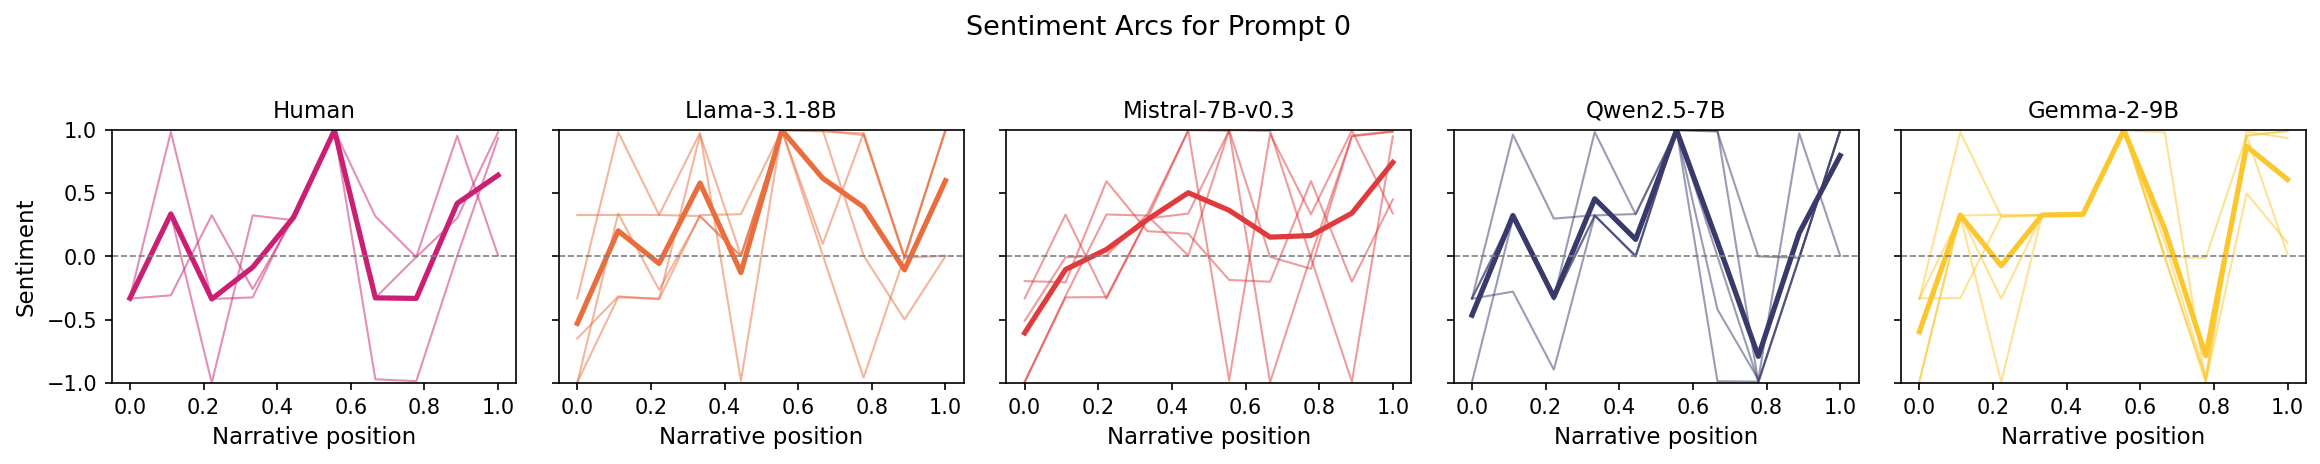

In [34]:
# Show sentiment arcs for one prompt across all sources
example_prompt = df_valid['prompt_id'].iloc[0]
subset = df_valid[df_valid['prompt_id'] == example_prompt]
present_sources = [s for s in SOURCES if s in subset['source'].unique()]

# Plot sentiment arcs for the example prompt
fig, axes = plt.subplots(1, len(present_sources), figsize=(3.15 * len(present_sources), 3), sharey=True)
axes = np.atleast_1d(axes)
x = np.linspace(0, 1, ARC_LENGTH)

for ax, source in zip(axes, present_sources):
    label = MODEL_LABELS[source]
    color = MODEL_COLORS[label]
    arcs = subset[subset['source'] == source]['sentiment_arc'].tolist()
    for arc in arcs:
        ax.plot(x, arc, alpha=0.5, color=color, linewidth=1)
    if arcs:
        mean_arc = np.mean(arcs, axis=0)
        ax.plot(x, mean_arc, color=color, linewidth=2.5, label='mean')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Narrative position')
    ax.set_ylim(-1, 1)

axes[0].set_ylabel('Sentiment')
fig.suptitle(f'Sentiment Arcs for Prompt {example_prompt}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sentiment_arcs_example.png', dpi=300, bbox_inches='tight')
plt.show()

## Compute D_narr per Prompt and Source

In [35]:
def mean_pairwise_l2(arcs):
    # Compute mean pairwise Euclidean distance between a list of arc vectors
    # Returns 0.0 if fewer than 2 arcs
    if len(arcs) < 2:
        return 0.0

    # Convert the list of arcs to a NumPy array for efficient computation
    arcs_arr = np.array(arcs)

    # Compute pairwise Euclidean distances between all unique pairs of arcs
    dists = [np.linalg.norm(arcs_arr[i] - arcs_arr[j]) for i, j in combinations(range(len(arcs_arr)), 2)]

    # Return the mean of the pairwise distances
    return np.mean(dists)


# Compute D_narr for each (prompt_id, source) pair
results = []
for (prompt_id, source), group in df_valid.groupby(['prompt_id', 'source']):
    arcs = group['sentiment_arc'].tolist()
    d_narr = mean_pairwise_l2(arcs)
    results.append({'prompt_id': prompt_id, 'source': source, 'n_stories': len(arcs), 'D_narr': d_narr})

df_narr = pd.DataFrame(results)

# Drop groups with too few valid stories: their pairwise diversity is degenerate/undefined
n_before = len(df_narr)
df_narr = df_narr[df_narr['n_stories'] >= MIN_STORIES_PER_GROUP].reset_index(drop=True)
df_narr['model'] = df_narr['source'].map(MODEL_LABELS)

print(f"Dropped {n_before - len(df_narr)} (prompt, source) groups with < {MIN_STORIES_PER_GROUP} valid stories.")
print(f"Computed D_narr for {len(df_narr)} (prompt, source) pairs.")

d_narr_descriptives = df_narr.groupby('source')['D_narr'].describe().round(4)
d_narr_descriptives.to_csv(TABLE_DIR / 'd_narr_descriptives_by_source.csv')
d_narr_descriptives

Dropped 28 (prompt, source) groups with < 2 valid stories.
Computed D_narr for 953 (prompt, source) pairs.


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
gemma,194.0,1.9403,0.7892,0.0080,1.4187,1.9187,2.4140,4.2297
human,184.0,2.7201,0.8640,0.0306,2.1187,2.7684,3.2672,4.8822
llama,198.0,2.0887,0.7548,0.0069,1.5819,2.1189,2.5704,3.6972
mistral,199.0,1.9927,0.7178,0.0064,1.4960,2.0183,2.3619,3.6868
qwen,178.0,2.0200,0.7889,0.0055,1.5308,1.9747,2.4190,4.9616


## Diversity Profile D(t): Where in the Narrative Does Diversity Occur?

- D_narr collapses the full 10-point sentiment arc into a single pairwise distance per (prompt, source) group
- Hides where along the narrative the arcs actually diverge (two groups could have the same D_narr while diverging at completely different points in the story)
- Define a per-position diversity profile
$$D(t) = \frac{1}{\binom{n}{2}} \sum_{i<j} (a_i^{(t)} - a_j^{(t)})^2$$
- $\sum_t D(t)$ exactly equals the mean pairwise squared arc distance

In [36]:
def position_wise_diversity(arcs):
    # Mean pairwise squared difference at each narrative position.
    # Returns np.array of shape (ARC_LENGTH,), or None if fewer than 2 arcs.
    arcs_arr = np.array(arcs)

    # Return None if fewer than 2 arcs (pairwise diversity is undefined)
    if len(arcs_arr) < 2:
        return None

    # Compute pairwise squared differences for each narrative position
    diffs_sq = np.array([(arcs_arr[i] - arcs_arr[j]) ** 2 for i, j in combinations(range(len(arcs_arr)), 2)])

    # Return the mean of the pairwise squared differences at each position
    return diffs_sq.mean(axis=0)


# Compute diversity profile D(t) for each (prompt_id, source) pair
profile_results = []
for (prompt_id, source), group in df_valid.groupby(['prompt_id', 'source']):
    arcs = group['sentiment_arc'].tolist()
    profile = position_wise_diversity(arcs)
    if profile is None:
        continue
    profile_results.append({'prompt_id': prompt_id, 'source': source, 'profile': profile, 'n_stories': len(arcs)})

df_profile = pd.DataFrame(profile_results)

# Same degenerate-group filter as for D_narr (mean pairwise L2 distance): drop (prompt, source) groups with too few valid stories
n_before = len(df_profile)
df_profile = df_profile[df_profile['n_stories'] >= MIN_STORIES_PER_GROUP].reset_index(drop=True)


print(f"Dropped {n_before - len(df_profile)} (prompt, source) groups with < {MIN_STORIES_PER_GROUP} valid stories.")
print(f"Computed diversity profiles for {len(df_profile)} (prompt, source) pairs.")

Dropped 0 (prompt, source) groups with < 2 valid stories.
Computed diversity profiles for 953 (prompt, source) pairs.


In [37]:
# Sanity check: sum_t D(t) must equal the mean pairwise squared arc distance
def mean_pairwise_sq_l2(arcs):
    arcs_arr = np.array(arcs)

    if len(arcs_arr) < 2:
        return np.nan

    dists_sq = [np.sum((arcs_arr[i] - arcs_arr[j]) ** 2) for i, j in combinations(range(len(arcs_arr)), 2)]
    return np.mean(dists_sq)

check = (
    df_valid.groupby(['prompt_id', 'source'])['sentiment_arc']
    .apply(lambda g: mean_pairwise_sq_l2(g.tolist()))
    .reset_index(name='mean_sq_l2')
)


df_profile = df_profile.merge(check, on=['prompt_id', 'source'])
df_profile['sum_profile'] = df_profile['profile'].apply(np.sum)
df_profile['D_narr_rms'] = np.sqrt(df_profile['sum_profile'])

max_diff = (df_profile['sum_profile'] - df_profile['mean_sq_l2']).abs().max()
print(f"Decomposition check: max |sum_t D(t) - mean pairwise squared L2| = {max_diff:.2e}")

# Compare the RMS variant to the originally reported (non-squared) D_narr
comparison = df_profile.merge(df_narr, on=['prompt_id', 'source'])
r_check = np.corrcoef(comparison['D_narr'], comparison['D_narr_rms'])[0, 1]


print(f"\nCorrelation D_narr (reported) vs. D_narr_rms (sqrt of decomposed profile): r = {r_check:.3f}")
print(comparison[['D_narr', 'D_narr_rms']].describe().round(4))

Decomposition check: max |sum_t D(t) - mean pairwise squared L2| = 5.33e-15

Correlation D_narr (reported) vs. D_narr_rms (sqrt of decomposed profile): r = 0.992
         D_narr  D_narr_rms
count  953.0000    953.0000
mean     2.1475      2.2507
std      0.8315      0.8206
min      0.0055      0.0060
25%      1.5825      1.6906
50%      2.0981      2.2210
75%      2.6801      2.7821
max      4.9616      4.9616


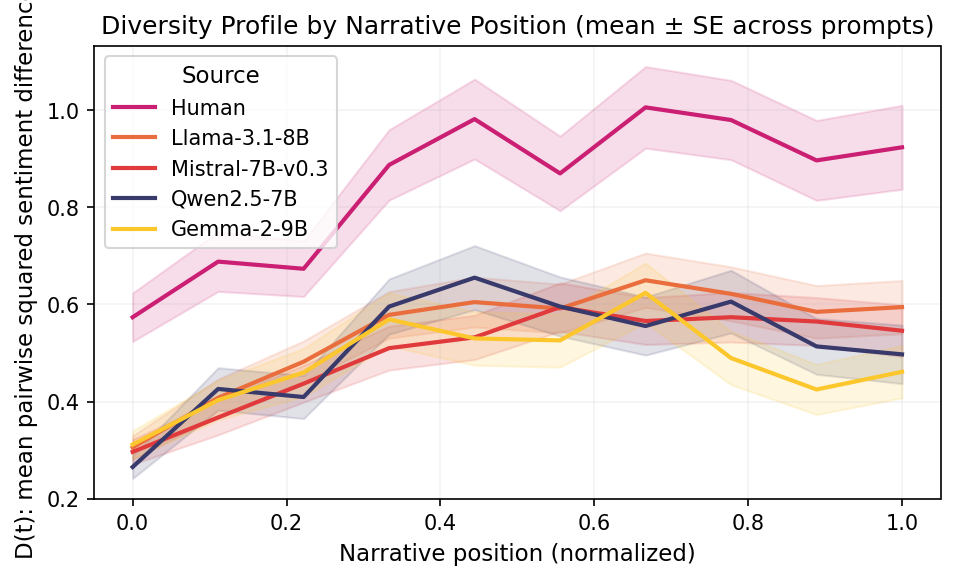

In [38]:
# Plot: diversity profile D(t) by narrative position, per source (mean +/- SE across prompts)
x = np.linspace(0, 1, ARC_LENGTH)

fig, ax = plt.subplots(figsize=(6.5, 4))
for source in SOURCES:
    sub = df_profile[df_profile['source'] == source]
    if sub.empty:
        continue
    profiles = np.array(sub['profile'].tolist())
    mean_profile = profiles.mean(axis=0)
    se_profile = profiles.std(axis=0) / np.sqrt(len(profiles))
    label = MODEL_LABELS[source]
    color = MODEL_COLORS[label]
    ax.plot(x, mean_profile, label=label, color=color, linewidth=2)
    ax.fill_between(x, mean_profile - se_profile, mean_profile + se_profile, alpha=0.15, color=color)

ax.set_xlabel('Narrative position (normalized)')
ax.set_ylabel('D(t): mean pairwise squared sentiment difference')
ax.set_title('Diversity Profile by Narrative Position (mean ± SE across prompts)', fontsize=12)
ax.legend(title='Source')
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig(FIG_DIR / 'diversity_profile_by_position.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# Where in the story is diversity concentrated?
position_labels = np.linspace(0, 1, ARC_LENGTH)
third = ARC_LENGTH // 3

print('Narrative position of maximum diversity, by source:')
for source in SOURCES:
    sub = df_profile[df_profile['source'] == source]
    if sub.empty:
        continue
    profiles = np.array(sub['profile'].tolist())
    mean_profile = profiles.mean(axis=0)
    peak_idx = np.argmax(mean_profile)
    print(f'  {MODEL_LABELS[source]:18s}: peak at position {position_labels[peak_idx]:.2f}  (D(t)={mean_profile[peak_idx]:.4f})')

print()
print('Diversity in the first third (setup) vs. last third (resolution) of the story:')
for source in SOURCES:
    sub = df_profile[df_profile['source'] == source]
    if sub.empty:
        continue
    profiles = np.array(sub['profile'].tolist())
    mean_profile = profiles.mean(axis=0)
    early = mean_profile[:third].mean()
    late = mean_profile[-third:].mean()
    print(f'  {MODEL_LABELS[source]:18s}: early={early:.4f}, late={late:.4f}, ratio(early/late)={early / late:.2f}')

Narrative position of maximum diversity, by source:
  Human             : peak at position 0.67  (D(t)=1.0059)
  Llama-3.1-8B      : peak at position 0.67  (D(t)=0.6499)
  Mistral-7B-v0.3   : peak at position 0.56  (D(t)=0.5946)
  Qwen2.5-7B        : peak at position 0.44  (D(t)=0.6552)
  Gemma-2-9B        : peak at position 0.67  (D(t)=0.6238)

Diversity in the first third (setup) vs. last third (resolution) of the story:
  Human             : early=0.6451, late=0.9334, ratio(early/late)=0.69
  Llama-3.1-8B      : early=0.3984, late=0.6004, ratio(early/late)=0.66
  Mistral-7B-v0.3   : early=0.3668, late=0.5615, ratio(early/late)=0.65
  Qwen2.5-7B        : early=0.3668, late=0.5389, ratio(early/late)=0.68
  Gemma-2-9B        : early=0.3914, late=0.4586, ratio(early/late)=0.85


## Descriptive Analysis

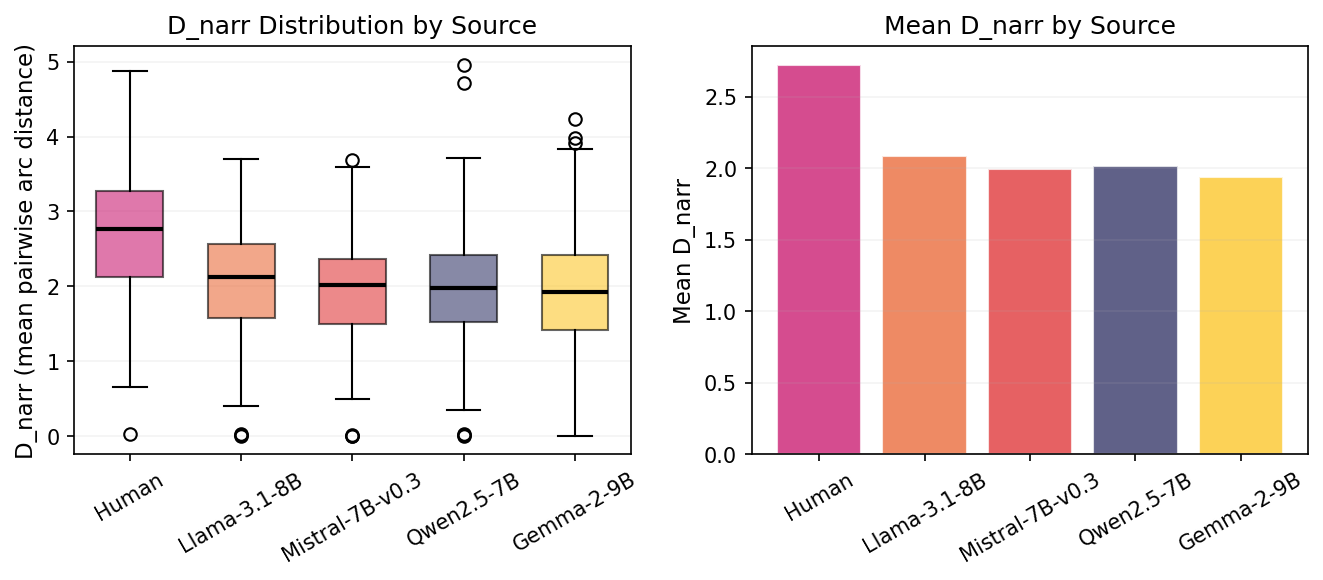

,mean,std
Human,2.7201,0.8640
Llama-3.1-8B,2.0887,0.7548
Mistral-7B-v0.3,1.9927,0.7178
Qwen2.5-7B,2.0200,0.7889
Gemma-2-9B,1.9403,0.7892


In [40]:
# D_narr by source
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

source_order = df_narr.groupby('source')['D_narr'].median().sort_values(ascending=False).index.tolist()
label_order = [MODEL_LABELS[s] for s in source_order]
colors_order = [MODEL_COLORS[l] for l in label_order]

data = [df_narr[df_narr['source'] == s]['D_narr'].values for s in source_order]
bp = axes[0].boxplot(data, labels=label_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2), widths=0.6)
for patch, color in zip(bp['boxes'], colors_order):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_title('D_narr Distribution by Source', fontsize=12)
axes[0].set_ylabel('D_narr (mean pairwise arc distance)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.15, axis='y')

means = df_narr.groupby('source')['D_narr'].mean().reindex(source_order)
axes[1].bar(label_order, means.values, color=colors_order, edgecolor='white', alpha=0.8)
axes[1].set_title('Mean D_narr by Source', fontsize=12)
axes[1].set_ylabel('Mean D_narr')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.15, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'narrative_by_source.png', dpi=300, bbox_inches='tight')
plt.show()

d_narr_mean_std = df_narr.groupby('source')['D_narr'].agg(['mean', 'std']).reindex(source_order).round(4)
d_narr_mean_std.index = label_order
d_narr_mean_std.to_csv(TABLE_DIR / 'd_narr_mean_std_by_source.csv')
d_narr_mean_std

## Mean Sentiment Arcs per Source (Aggregate)

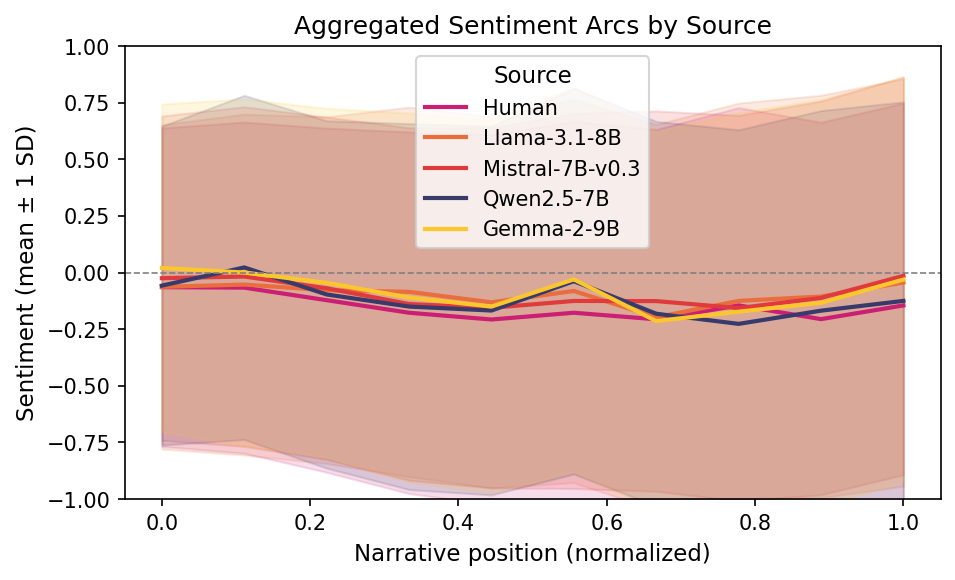

In [41]:
fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.linspace(0, 1, ARC_LENGTH)

for source in SOURCES:
    source_arcs = df_valid[df_valid['source'] == source]['sentiment_arc'].tolist()
    if not source_arcs:
        continue
    mean_arc = np.mean(source_arcs, axis=0)
    std_arc = np.std(source_arcs, axis=0)
    label = MODEL_LABELS[source]
    color = MODEL_COLORS[label]
    ax.plot(x, mean_arc, label=label, color=color, linewidth=2)
    ax.fill_between(x, mean_arc - std_arc, mean_arc + std_arc, alpha=0.15, color=color)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Narrative position (normalized)')
ax.set_ylabel('Sentiment (mean ± 1 SD)')
ax.set_title('Aggregated Sentiment Arcs by Source', fontsize=12)
ax.legend(title='Source')
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / 'aggregated_sentiment_arcs.png', dpi=300, bbox_inches='tight')
plt.show()

## Arc-Shape-Classification

k-means with k=6 on all sentiment-arcs using the six basic forms of emotional arcs (Reagan et al., 2016): *Rags to Riches*, *Tragedy*, *Man in a Hole*, *Icarus*, *Cinderella*, *Oedipus*.

### Validating the Choice of k

check whether k=6 is actually well-supported by this dataset's own clustering structure:
1. Elbow method: inertia -> always decreases with k, requires a subjective visual judgment of where returns diminish
2. Silhouette score: mean, over all points, of how much closer each point is to its own cluster than to the next-best cluster,  ranges [-1, 1], forms an actual maximum rather than a subjective bend

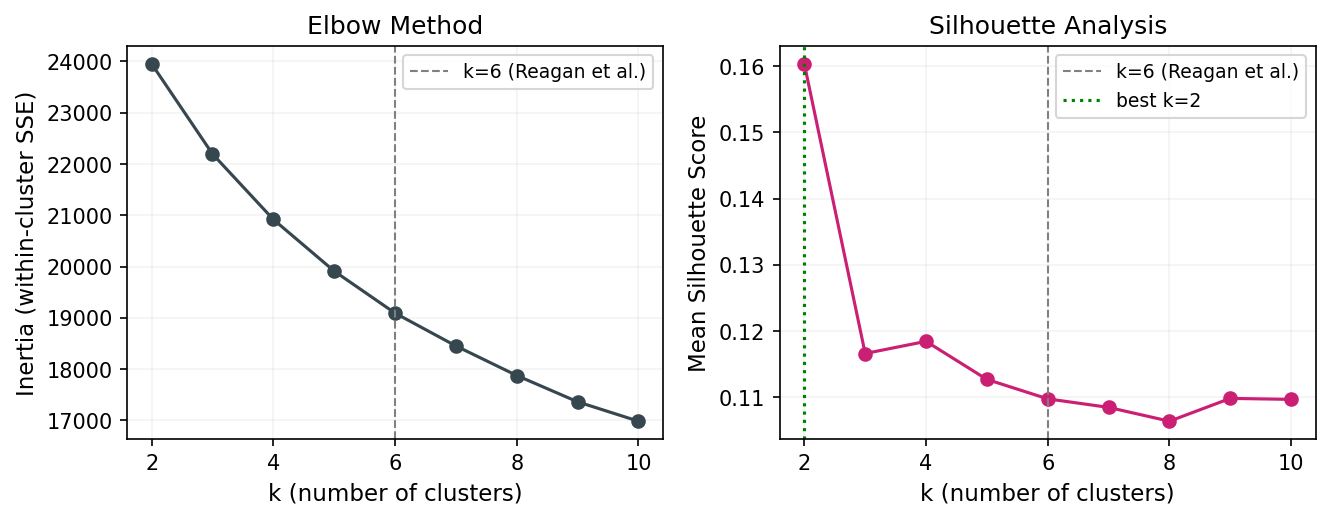

k, inertia, silhouette:
  k= 2: inertia=  23953.70, silhouette=0.1603
  k= 3: inertia=  22196.62, silhouette=0.1166
  k= 4: inertia=  20919.11, silhouette=0.1184
  k= 5: inertia=  19911.31, silhouette=0.1127
  k= 6: inertia=  19091.61, silhouette=0.1098
  k= 7: inertia=  18451.30, silhouette=0.1085
  k= 8: inertia=  17874.80, silhouette=0.1064
  k= 9: inertia=  17361.55, silhouette=0.1098
  k=10: inertia=  16983.16, silhouette=0.1097


In [43]:
arc_matrix_check = np.array(df_valid['sentiment_arc'].tolist())

# KMeans clustering validation: elbow method and silhouette analysis
k_range = list(range(2, 11))
inertias = []
silhouettes = []

# Fit KMeans for each k and compute inertia and silhouette score
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(arc_matrix_check)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(arc_matrix_check, labels))

best_k = k_range[int(np.argmax(silhouettes))]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

axes[0].plot(k_range, inertias, marker='o', color='#37474F')
axes[0].axvline(6, color='gray', linestyle='--', linewidth=1, label='k=6 (Reagan et al.)')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.15)

axes[1].plot(k_range, silhouettes, marker='o', color='#cb1f73')
axes[1].axvline(6, color='gray', linestyle='--', linewidth=1, label='k=6 (Reagan et al.)')
axes[1].axvline(best_k, color='green', linestyle=':', linewidth=1.5, label=f'best k={best_k}')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_title('Silhouette Analysis', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_k_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print('k, inertia, silhouette:')
for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f'  k={k:2d}: inertia={inertia:10.2f}, silhouette={sil:.4f}')

In [44]:
# Arc-Matrix from all valid stories: each row is a story, each column is a point in the sentiment arc
arc_matrix = np.array(df_valid['sentiment_arc'].tolist())
df_valid = df_valid.reset_index(drop=True).copy()

# k-means with k=6
N_SHAPES = 6
kmeans = KMeans(n_clusters=N_SHAPES, random_state=42, n_init=20)
kmeans.fit(arc_matrix)
df_valid['arc_shape'] = kmeans.labels_

# Sort cluster by mean sentiment (positive to negative)
centroids = kmeans.cluster_centers_
shape_order = np.argsort(centroids.mean(axis=1))[::-1]
shape_remap = {int(old): int(new) for new, old in enumerate(shape_order)}
df_valid['arc_shape'] = df_valid['arc_shape'].map(shape_remap)
centroids = centroids[shape_order]

print(f'k-means with k={N_SHAPES} on {len(arc_matrix):,} sentiment-arcs')
print(f'\nCluster sizes:')


for i in range(N_SHAPES):
    n = (df_valid['arc_shape'] == i).sum()
    print(f'  Shape {i}: {n:4d} stories ({n / len(df_valid) * 100:.1f}%)')

k-means with k=6 on 4,244 sentiment-arcs

Cluster sizes:
  Shape 0:  652 stories (15.4%)
  Shape 1:  528 stories (12.4%)
  Shape 2:  854 stories (20.1%)
  Shape 3:  622 stories (14.7%)
  Shape 4:  708 stories (16.7%)
  Shape 5:  880 stories (20.7%)


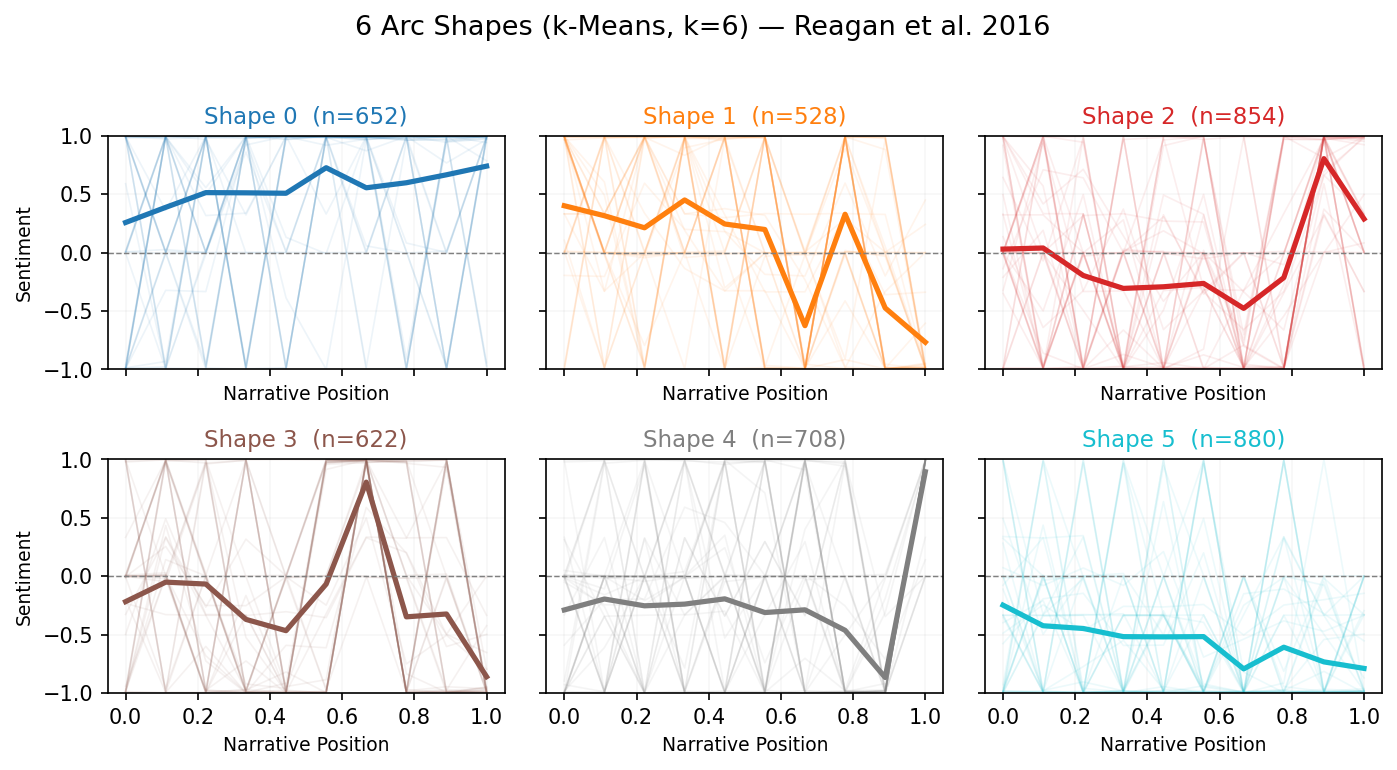

In [45]:
# Visualize 6 arc shapes: centroids + background arcs
SHAPE_COLORS = plt.cm.tab10(np.linspace(0, 0.9, N_SHAPES))
x = np.linspace(0, 1, ARC_LENGTH)

fig, axes = plt.subplots(2, 3, figsize=(9.5, 5), sharey=True, sharex=True)
axes = axes.flatten()

# Plot each cluster's arcs and centroid
for i, ax in enumerate(axes):
    mask = df_valid['arc_shape'] == i
    cluster_arcs = arc_matrix[mask.values]
    n_show = min(40, len(cluster_arcs))
    sample_idx = np.random.choice(len(cluster_arcs), n_show, replace=False)


    for arc in cluster_arcs[sample_idx]:
        ax.plot(x, arc, alpha=0.08, color=SHAPE_COLORS[i], linewidth=0.8)

    ax.plot(x, centroids[i], color=SHAPE_COLORS[i], linewidth=2.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.set_ylim(-1, 1)
    ax.set_title(f'Shape {i}  (n={mask.sum()})', fontsize=11, color=SHAPE_COLORS[i])
    ax.set_xlabel('Narrative Position', fontsize=9)

    if i % 3 == 0:
        ax.set_ylabel('Sentiment', fontsize=9)
        
    ax.grid(True, alpha=0.1)

fig.suptitle('6 Arc Shapes (k-Means, k=6) — Reagan et al. 2016', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'arc_shapes_kmeans.png', dpi=300, bbox_inches='tight')
plt.show()

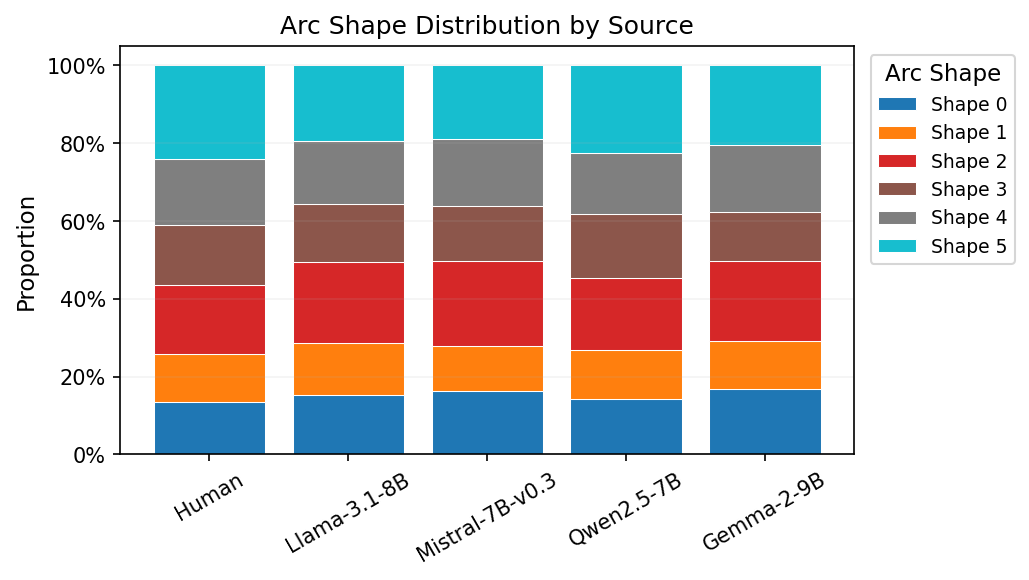

Entropy of arc shape distribution by source:
  (max. at uniform distribution: 2.585 bit)

  Human             : H = 2.550 bit  █████████████████████████
  Llama-3.1-8B      : H = 2.568 bit  █████████████████████████
  Mistral-7B-v0.3   : H = 2.556 bit  █████████████████████████
  Qwen2.5-7B        : H = 2.559 bit  █████████████████████████
  Gemma-2-9B        : H = 2.556 bit  █████████████████████████


In [46]:
# Arc shape distribution by source (stacked bar chart)
shape_dist = df_valid.groupby(['source', 'arc_shape']).size().unstack(fill_value=0)
present_sources = [s for s in SOURCES if s in shape_dist.index]

# Normalize to proportions for stacked bar chart
shape_dist_norm = shape_dist.div(shape_dist.sum(axis=1), axis=0).reindex(present_sources)
present_labels = [MODEL_LABELS[s] for s in present_sources]

fig, ax = plt.subplots(figsize=(7, 4))
bottom = np.zeros(len(present_sources))

# Stacked bar chart: each shape's proportion per source
for i in range(N_SHAPES):
    vals = shape_dist_norm[i].values
    ax.bar(present_labels, vals, bottom=bottom, label=f'Shape {i}',
           color=SHAPE_COLORS[i], edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_ylabel('Proportion')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title('Arc Shape Distribution by Source', fontsize=12)
ax.legend(title='Arc Shape', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.15, axis='y')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / 'arc_shape_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Entropy of arc shape distribution by source
print('Entropy of arc shape distribution by source:')
print(f'  (max. at uniform distribution: {np.log2(N_SHAPES):.3f} bit)')
print()

for source in present_sources:
    dist = shape_dist_norm.loc[source].values
    ent = scipy_entropy(dist, base=2)
    bar = '█' * int(ent * 10)
    
    print(f'  {MODEL_LABELS[source]:18s}: H = {ent:.3f} bit  {bar}')

## Which Source Prefers Which Arc Shape?

In [47]:
# Aggregate to one arc-shape per (prompt, source) group to avoid pseudo-replication
group_mean_arcs = (
    df_valid.groupby(['prompt_id', 'source'])['sentiment_arc']
    .apply(lambda g: np.mean(np.array(g.tolist()), axis=0))
)

# Filter out any (prompt, source) groups that don't exist in the original df_narr (e.g., dropped for too few stories)
valid_keys = set(zip(df_narr['prompt_id'], df_narr['source']))
group_mean_arcs = group_mean_arcs[[k in valid_keys for k in group_mean_arcs.index]]

# Compute the arc shape for each (prompt, source) group by predicting the cluster label of the mean arc
mean_arc_matrix = np.stack(group_mean_arcs.values)
mean_labels_raw = kmeans.predict(mean_arc_matrix)
mean_labels = np.array([shape_remap[int(l)] for l in mean_labels_raw])

# Create a DataFrame with the aggregated (prompt, source) groups and their corresponding arc shapes
shape_group = pd.DataFrame({
    'prompt_id': [k[0] for k in group_mean_arcs.index],
    'source': [k[1] for k in group_mean_arcs.index],
    'arc_shape': mean_labels,
})

# Aggregate the arc shape counts by source and arc shape, filling in any missing combinations with zeros
shape_dist_agg = (
    shape_group.groupby(['source', 'arc_shape']).size()
    .unstack(fill_value=0)
    .reindex(index=present_sources, columns=range(N_SHAPES), fill_value=0)
)

print(f"Aggregated {len(df_valid)} individual stories -> {len(shape_group)} (prompt, source) groups.")
print(shape_dist_agg.rename(index=MODEL_LABELS))

# Chi-square test of independence on the aggregated (independent) groups
chi2_agg, p_chi2_agg, dof_agg, expected_agg = chi2_contingency(shape_dist_agg.values)

# Cramer's V: effect size for chi-square test of independence
cramers_v_agg = np.sqrt(chi2_agg / (shape_dist_agg.values.sum() * (min(shape_dist_agg.shape) - 1)))

print("\nChi-square test of independence (source x arc shape), prompt-level aggregated:")
print(f"  N = {shape_dist_agg.values.sum()}, chi2 = {chi2_agg:.2f}, dof = {dof_agg}, p = {p_chi2_agg:.2e}")
print(f"  Cramer's V = {cramers_v_agg:.3f}")

# For comparison: the naive test on all individual (pseudo-replicated) stories
chi2, p_chi2, dof, expected = chi2_contingency(shape_dist.values)
cramers_v = np.sqrt(chi2 / (shape_dist.values.sum() * (min(shape_dist.shape) - 1)))

print(f"  chi2 = {chi2:.2f}, dof = {dof}, p = {p_chi2:.2e}, Cramer's V = {cramers_v:.3f}")

# Standardized residuals on the aggregated table: (observed - expected) / sqrt(expected)
# Positive = source uses this shape more than chance, negative = less

std_resid = (shape_dist_agg.values - expected_agg) / np.sqrt(expected_agg)
df_resid = pd.DataFrame(std_resid, index=[MODEL_LABELS[s] for s in shape_dist_agg.index], columns=shape_dist_agg.columns)
df_resid.columns = [f'Shape {i}' for i in df_resid.columns]
df_resid.to_csv(TABLE_DIR / 'arc_shape_standardized_residuals.csv')

print("\nStandardized residuals (source x shape), prompt-level aggregated:")
print(df_resid.round(2))

Aggregated 4244 individual stories -> 953 (prompt, source) groups.
arc_shape         0   1   2   3   4   5
source                                 
Human            26  23  40  20  27  48
Llama-3.1-8B     29  30  38  27  25  49
Mistral-7B-v0.3  36  19  44  25  34  41
Qwen2.5-7B       30  22  34  30  22  40
Gemma-2-9B       35  24  38  25  28  44

Chi-square test of independence (source x arc shape), prompt-level aggregated:
  N = 953, chi2 = 11.04, dof = 20, p = 9.45e-01
  Cramer's V = 0.054
  chi2 = 22.50, dof = 20, p = 3.14e-01, Cramer's V = 0.036

Standardized residuals (source x shape), prompt-level aggregated:
                 Shape 0  Shape 1  Shape 2  Shape 3  Shape 4  Shape 5
Human              -0.75     0.05     0.42    -0.91     0.14     0.78
Llama-3.1-8B       -0.60     1.11    -0.36     0.12    -0.61     0.42
Mistral-7B-v0.3     0.60    -1.14     0.55    -0.30     1.05    -0.79
Qwen2.5-7B          0.16    -0.01    -0.37     1.29    -0.67    -0.23
Gemma-2-9B          0.58    

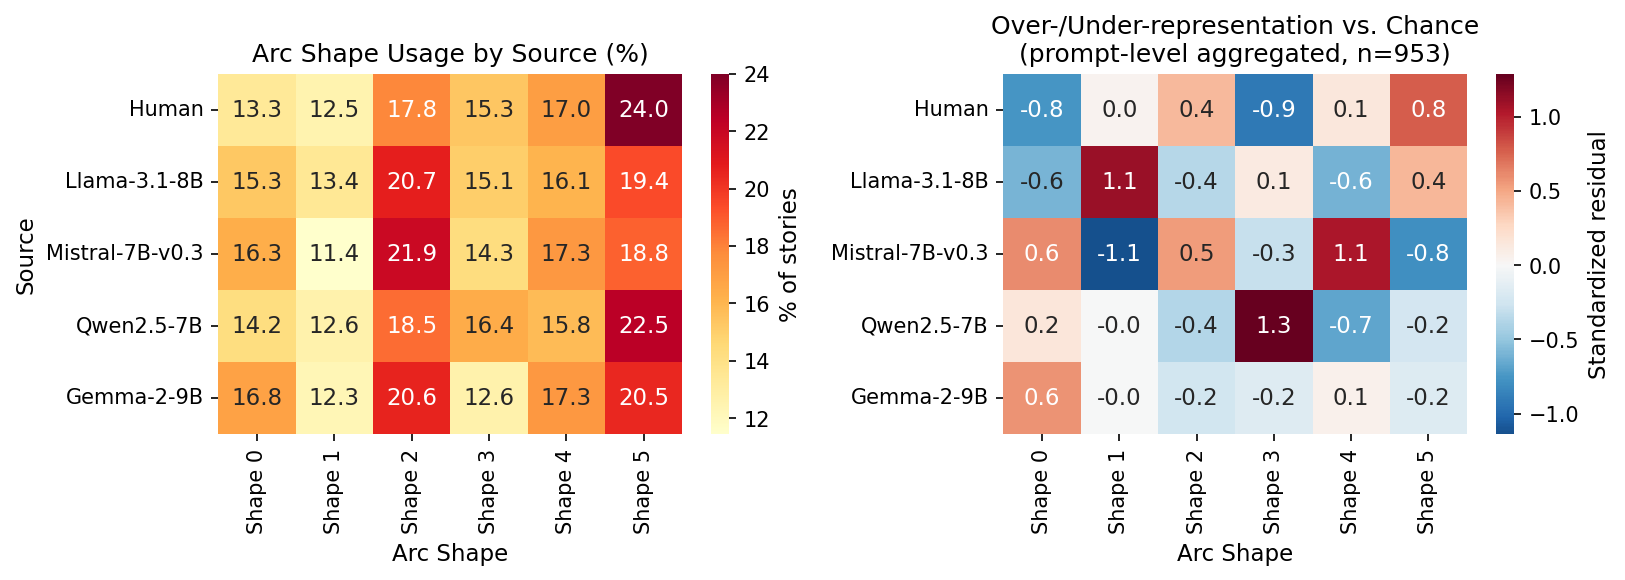

In [48]:
# Heatmaps: usage share and over-/under-representation vs. chance
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(shape_dist_norm.rename(index=MODEL_LABELS) * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% of stories'}, ax=axes[0],
            xticklabels=[f'Shape {i}' for i in range(N_SHAPES)])
axes[0].set_title('Arc Shape Usage by Source (%)', fontsize=12)
axes[0].set_xlabel('Arc Shape')
axes[0].set_ylabel('Source')

sns.heatmap(df_resid, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Standardized residual'}, ax=axes[1])
axes[1].set_title(f'Over-/Under-representation vs. Chance\n(prompt-level aggregated, n={int(shape_dist_agg.values.sum())})', fontsize=12)
axes[1].set_xlabel('Arc Shape')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(FIG_DIR / 'arc_shape_source_association.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
# Dominant arc shape per source
print('Dominant arc shape per source:')
print(f'{"Source":18s} {"Dominant Shape":>15} {"Share":>8} {"vs. chance (16.7%)":>20}')
print('-' * 65)

for source in present_sources:
    dist = shape_dist_norm.loc[source]
    dominant = dist.idxmax()
    share = dist.max()
    delta_pp = (share - 1 / N_SHAPES) * 100
    
    print(f'{MODEL_LABELS[source]:18s} {"Shape " + str(dominant):>15} {share * 100:>7.1f}% {delta_pp:>+19.1f}pp')

Dominant arc shape per source:
Source              Dominant Shape    Share   vs. chance (16.7%)
-----------------------------------------------------------------
Human                      Shape 5    24.0%                +7.3pp
Llama-3.1-8B               Shape 2    20.7%                +4.1pp
Mistral-7B-v0.3            Shape 2    21.9%                +5.2pp
Qwen2.5-7B                 Shape 5    22.5%                +5.8pp
Gemma-2-9B                 Shape 2    20.6%                +3.9pp


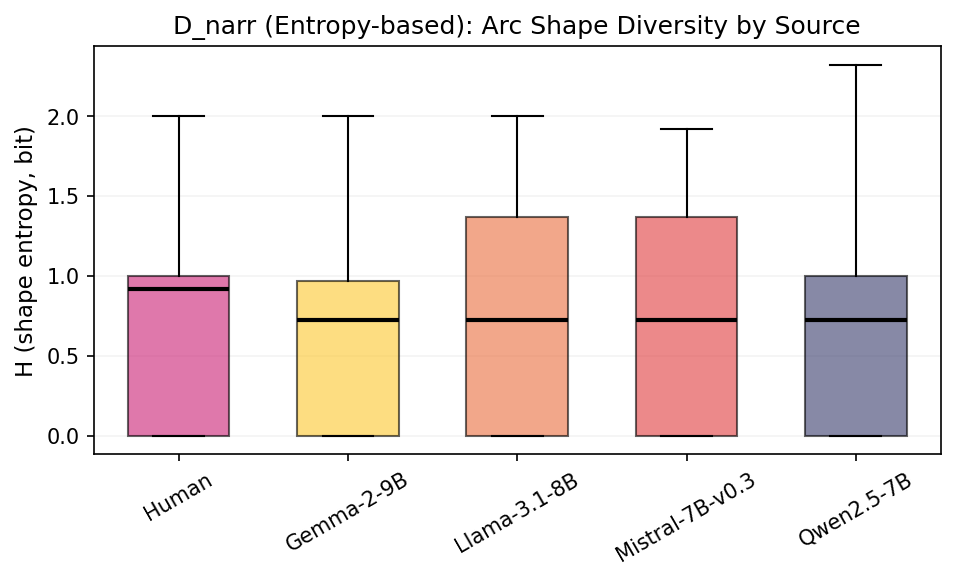

Correlation D_narr (distance) <-> D_narr (entropy):
  Pearson r = 0.501

Mean shape entropy by source:
  Human             : 0.829 ± 0.561 bit
  Llama-3.1-8B      : 0.720 ± 0.592 bit
  Mistral-7B-v0.3   : 0.746 ± 0.604 bit
  Qwen2.5-7B        : 0.721 ± 0.590 bit
  Gemma-2-9B        : 0.587 ± 0.561 bit


In [50]:
# Entropy-based D_narr per (prompt, source)
def shape_entropy(group):
    counts = group['arc_shape'].value_counts()
    return scipy_entropy((counts / counts.sum()).values, base=2)

entropy_results = (
    df_valid.groupby(['prompt_id', 'source'])
    .apply(shape_entropy)
    .reset_index(name='D_narr_entropy')
)

# Restrict to the same non-degenerate groups as D_narr (inner join on the already-filtered df_narr).
entropy_results = entropy_results.merge(df_narr[['prompt_id', 'source']], on=['prompt_id', 'source'])

# Boxplot: entropy-based D_narr by source
fig, ax = plt.subplots(figsize=(6.5, 4))
ent_order = entropy_results.groupby('source')['D_narr_entropy'].median().sort_values(ascending=False).index.tolist()
ent_labels = [MODEL_LABELS[s] for s in ent_order]
ent_colors = [MODEL_COLORS[l] for l in ent_labels]
data_ent = [entropy_results[entropy_results['source'] == s]['D_narr_entropy'].values for s in ent_order]
bp = ax.boxplot(data_ent, labels=ent_labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=2), widths=0.6)
for patch, color in zip(bp['boxes'], ent_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title('D_narr (Entropy-based): Arc Shape Diversity by Source', fontsize=12)
ax.set_ylabel('H (shape entropy, bit)')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'd_narr_entropy_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation with distance-based D_narr
merged = df_narr[['prompt_id', 'source', 'D_narr']].merge(entropy_results, on=['prompt_id', 'source'])
r = np.corrcoef(merged['D_narr'], merged['D_narr_entropy'])[0, 1]
print(f'Correlation D_narr (distance) <-> D_narr (entropy):')
print(f'  Pearson r = {r:.3f}')
print()
print('Mean shape entropy by source:')

for source in present_sources:
    vals = entropy_results[entropy_results['source'] == source]['D_narr_entropy']
    print(f'  {MODEL_LABELS[source]:18s}: {vals.mean():.3f} ± {vals.std():.3f} bit')

entropy_results.to_csv(TABLE_DIR / 'd_narr_entropy_by_group.csv', index=False)

## Statistical Testing: Does Source Affect D_narr?

In [51]:
groups = [df_narr[df_narr['source'] == s]['D_narr'].values for s in present_sources]

# Kruskal-Wallis
stat, p = kruskal(*groups)

print(f"Kruskal-Wallis test across sources:")
print(f"  H = {stat:.4f}, p = {p:.4f}")

# Interpret the result
if p < 0.05:
    print("  -> Significant difference in D_narr across sources (p < 0.05)")
else:
    print("  -> No significant difference detected (p >= 0.05)")

# Save the Kruskal-Wallis test result to a CSV file
pd.DataFrame([{'H': stat, 'p': p}]).to_csv(TABLE_DIR / 'd_narr_kruskal_wallis.csv', index=False)

print("\nPairwise Mann-Whitney U tests (Bonferroni corrected):")
pairs = list(combinations(present_sources, 2))
alpha_corrected = 0.05 / len(pairs)
print(f"  Bonferroni threshold: p < {alpha_corrected:.4f}")

# Perform pairwise Mann-Whitney U tests and save results
mw_rows = []
for s1, s2 in pairs:
    g1 = df_narr[df_narr['source'] == s1]['D_narr'].values
    g2 = df_narr[df_narr['source'] == s2]['D_narr'].values
    u, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '***' if p_mw < alpha_corrected else ('*' if p_mw < 0.05 else 'ns')
    print(f"  {MODEL_LABELS[s1]:18s} vs {MODEL_LABELS[s2]:18s}: U={u:.0f}, p={p_mw:.4f}  {sig}")
    mw_rows.append({'source_1': s1, 'source_2': s2, 'U': u, 'p': p_mw, 'sig': sig})

pd.DataFrame(mw_rows).to_csv(TABLE_DIR / 'd_narr_mannwhitney_pairwise.csv', index=False)

Kruskal-Wallis test across sources:
  H = 103.3074, p = 0.0000
  -> Significant difference in D_narr across sources (p < 0.05)

Pairwise Mann-Whitney U tests (Bonferroni corrected):
  Bonferroni threshold: p < 0.0050
  Human              vs Llama-3.1-8B      : U=25809, p=0.0000  ***
  Human              vs Mistral-7B-v0.3   : U=27256, p=0.0000  ***
  Human              vs Qwen2.5-7B        : U=24068, p=0.0000  ***
  Human              vs Gemma-2-9B        : U=26881, p=0.0000  ***
  Llama-3.1-8B       vs Mistral-7B-v0.3   : U=21630, p=0.0916  ns
  Llama-3.1-8B       vs Qwen2.5-7B        : U=19063, p=0.1710  ns
  Llama-3.1-8B       vs Gemma-2-9B        : U=21706, p=0.0258  *
  Mistral-7B-v0.3    vs Qwen2.5-7B        : U=17568, p=0.8927  ns
  Mistral-7B-v0.3    vs Gemma-2-9B        : U=20124, p=0.4661  ns
  Qwen2.5-7B         vs Gemma-2-9B        : U=18204, p=0.3655  ns


## Effect Size: Human vs. LLM

In [52]:
def cohens_d(a, b):
    '''Compute Cohen's d effect size between two arrays'''
    na, nb = len(a), len(b)

    # Pooled standard deviation
    pooled_std = np.sqrt(((na - 1) * a.std()**2 + (nb - 1) * b.std()**2) / (na + nb - 2))

    # Compute Cohen's d
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0

print('Effect Size Human vs. Model for D_narr')
print(f'{"Model":<18} {"Cohen d":>10} {"Strength":>10} {"U-test p":>12}')
print('-' * 54)

h = df_narr[df_narr['source'] == 'human']['D_narr'].values
effect_rows = []

# Compare each model to human
for source in [s for s in present_sources if s != 'human']:
    m = df_narr[df_narr['source'] == source]['D_narr'].values
    d = cohens_d(h, m)
    _, p_val = mannwhitneyu(h, m, alternative='two-sided')
    strength = 'large' if abs(d) > 0.8 else 'medium' if abs(d) > 0.5 else 'small'
    print(f'{MODEL_LABELS[source]:<18} {d:>+10.3f} {strength:>10} {p_val:>12.2e}')
    effect_rows.append({'model': MODEL_LABELS[source], 'cohens_d': d, 'strength': strength, 'u_test_p': p_val})

pd.DataFrame(effect_rows).to_csv(TABLE_DIR / 'd_narr_effect_size.csv', index=False)

Effect Size Human vs. Model for D_narr
Model                 Cohen d   Strength     U-test p
------------------------------------------------------
Llama-3.1-8B           +0.782     medium     1.91e-12
Mistral-7B-v0.3        +0.922      large     1.39e-16
Qwen2.5-7B             +0.848      large     1.10e-14
Gemma-2-9B             +0.946      large     1.79e-17


## Diversity Gap (Human, Model)

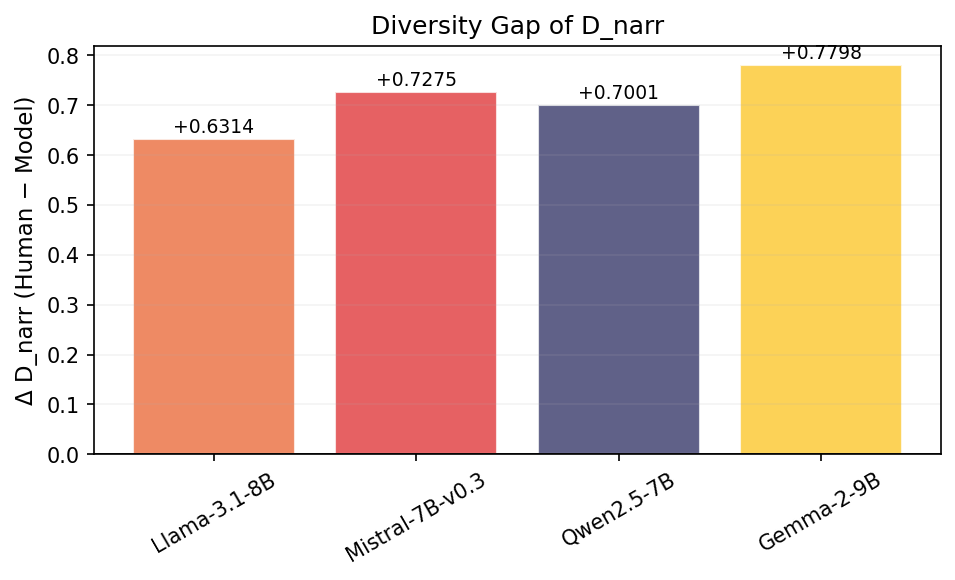


Diversity Gap (Human − Model):
  Llama-3.1-8B      : +0.6314
  Mistral-7B-v0.3   : +0.7275
  Qwen2.5-7B        : +0.7001
  Gemma-2-9B        : +0.7798


In [53]:
human_mean = df_narr[df_narr['source'] == 'human']['D_narr'].mean()
llm_sources = [s for s in present_sources if s != 'human']
llm_labels = [MODEL_LABELS[s] for s in llm_sources]

# Compute the diversity gap (Δ D_narr) between human and each model
deltas = [human_mean - df_narr[df_narr['source'] == s]['D_narr'].mean() for s in llm_sources]
colors_gap = [MODEL_COLORS[l] for l in llm_labels]

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(llm_labels, deltas, color=colors_gap, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Δ D_narr (Human − Model)')
ax.set_title('Diversity Gap of D_narr', fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')

for bar, delta in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width() / 2, delta + (0.005 if delta >= 0 else -0.012),
            f'{delta:+.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'diversity_gap_human_model.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nDiversity Gap (Human − Model):')
for l, d in zip(llm_labels, deltas):
    print(f'  {l:18s}: {d:+.4f}')

pd.DataFrame({'model': llm_labels, 'delta_D_narr': deltas}).to_csv(TABLE_DIR / 'd_narr_diversity_gap.csv', index=False)

## Export Results

In [54]:
out_path = TABLE_DIR / 'D_narr_results.csv'
df_narr.to_csv(out_path, index=False)
print(f"Saved D_narr results to: {out_path}")
df_narr.head(10)

Saved D_narr results to: ../../metrics/03_narrative_diversity/tables/translation_ref3/D_narr_results.csv


,prompt_id,source,n_stories,D_narr,model
0,0,gemma,5,1.613086,Gemma-2-9B
1,0,human,3,2.121312,Human
2,0,llama,5,2.181202,Llama-3.1-8B
3,0,mistral,5,2.456905,Mistral-7B-v0.3
4,0,qwen,5,1.920167,Qwen2.5-7B
5,1,gemma,5,0.694487,Gemma-2-9B
6,1,human,4,2.893260,Human
7,1,llama,5,2.558623,Llama-3.1-8B
8,1,mistral,5,1.344007,Mistral-7B-v0.3
9,1,qwen,5,2.052675,Qwen2.5-7B


# Appendix: VADER-based Sentiment Arcs (for Reference)

The analysis above uses a transformer-based sentiment classifier (`siebert/sentiment-roberta-large-english`) as its sentiment signal (unless `SENTIMENT_METHOD = 'vader'` above) -> this appendix runs the original VADER-based pipeline on the same texts and compares its D_narr against the transformer-based D_narr reported above.

In [55]:
# Recompute sentiment arcs with VADER (original lexicon-based approach) for reference
vader_analyzer = SentimentIntensityAnalyzer()

def get_sentiment_arc_vader(text, arc_length=ARC_LENGTH, min_sentences=MIN_SENTENCES):
    # Compute sentiment arc using VADER sentiment analysis
    sentences = sent_tokenize(text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 5]

    # Check if there are enough sentences
    if len(sentences) < min_sentences:
        return None

    # Compute sentiment scores for each sentence using VADER
    scores = [vader_analyzer.polarity_scores(s)['compound'] for s in sentences]
    return bin_to_arc(scores, arc_length)

df['sentiment_arc_vader'] = df['text'].apply(get_sentiment_arc_vader)
df_valid_vader = df.dropna(subset=['sentiment_arc_vader']).copy()

print(f"Valid VADER arcs: {len(df_valid_vader)}")

Valid VADER arcs: 4244


In [56]:
# D_narr with VADER arcs
results_vader = []

# Compute D_narr for each (prompt_id, source) pair using VADER arcs
for (prompt_id, source), group in df_valid_vader.groupby(['prompt_id', 'source']):
    arcs = group['sentiment_arc_vader'].tolist()
    d_narr = mean_pairwise_l2(arcs)
    results_vader.append({'prompt_id': prompt_id, 'source': source, 'n_stories': len(arcs), 'D_narr_vader': d_narr})

# Create a DataFrame for the VADER results and filter out groups with too few stories
df_narr_vader = pd.DataFrame(results_vader)
df_narr_vader = df_narr_vader[df_narr_vader['n_stories'] >= MIN_STORIES_PER_GROUP].reset_index(drop=True)

print("D_narr (VADER) by source:")
print(df_narr_vader.groupby('source')['D_narr_vader'].describe().round(4))

# Compare D_narr from transformer-based arcs vs. VADER arcs
comparison_vader = df_narr.merge(df_narr_vader, on=['prompt_id', 'source'])
r_vader = np.corrcoef(comparison_vader['D_narr'], comparison_vader['D_narr_vader'])[0, 1]

print(f"\nCorrelation D_narr (transformer) <-> D_narr (VADER): r = {r_vader:.3f}")

comparison_vader.to_csv(TABLE_DIR / 'd_narr_transformer_vs_vader.csv', index=False)

D_narr (VADER) by source:
         count    mean     std     min     25%     50%     75%     max
source                                                                
gemma    194.0  0.8002  0.3464  0.1606  0.5516  0.7546  0.9891  2.2488
human    184.0  1.2201  0.3897  0.1805  0.9096  1.2113  1.5177  2.4355
llama    198.0  0.8710  0.3445  0.1644  0.6122  0.8552  1.0526  1.9758
mistral  199.0  0.8082  0.3027  0.0508  0.5936  0.7692  1.0065  1.8108
qwen     178.0  0.8168  0.2946  0.1267  0.6273  0.7972  0.9786  1.5803

Correlation D_narr (transformer) <-> D_narr (VADER): r = 0.620


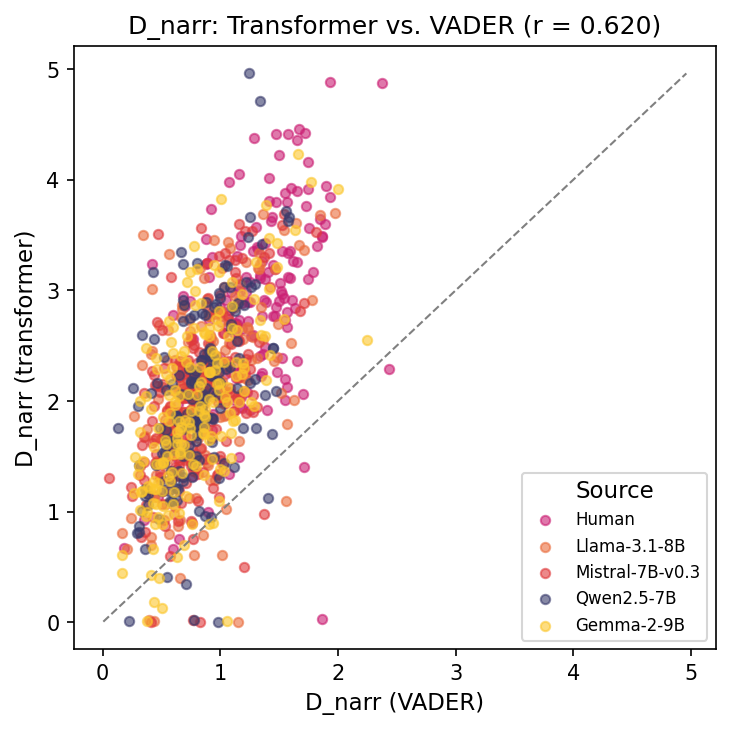

In [57]:
# Visual comparison: D_narr (transformer) vs. D_narr (VADER), per (prompt, source)
fig, ax = plt.subplots(figsize=(5, 5))
for source in present_sources:
    sub = comparison_vader[comparison_vader['source'] == source]
    label = MODEL_LABELS[source]
    ax.scatter(sub['D_narr_vader'], sub['D_narr'], color=MODEL_COLORS[label], alpha=0.6, label=label, s=20)

lims = [comparison_vader[['D_narr', 'D_narr_vader']].min().min(),
        comparison_vader[['D_narr', 'D_narr_vader']].max().max()]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('D_narr (VADER)')
ax.set_ylabel('D_narr (transformer)')
ax.set_title(f'D_narr: Transformer vs. VADER (r = {r_vader:.3f})', fontsize=12)
ax.legend(title='Source', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'd_narr_transformer_vs_vader.png', dpi=300, bbox_inches='tight')
plt.show()